In [1]:
import sys
from pathlib import Path

APP_DIR = Path.cwd().parent
sys.path.append(APP_DIR.as_posix())

In [2]:
# Chemins
OUTPUT_DIR = APP_DIR / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [4]:
import warnings

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import learning_curve
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.pipelines import MLPipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

c:\Users\Administrateur\Documents\M2i_CDSD_Projet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
ml_pipeline = MLPipeline()

train_dataset, validation_dataset, test_dataset = ml_pipeline._build_datasets()

print(f"Dimension jeu d'entrainement : {train_dataset.shape}")
print(f"Dimension jeu de validation : {validation_dataset.shape}")
print(f"Dimension jeu de test : {test_dataset.shape}")

Dimension jeu d'entrainement : (101152, 1326)
Dimension jeu de validation : (11072, 1326)
Dimension jeu de test : (13716, 1326)


In [6]:
def split_xy(
    dataset: pd.DataFrame,
    features: tuple[str],
) -> tuple[np.ndarray, np.ndarray]:
    feature_columns = [
        column for column in dataset.columns if column.startswith(features)
    ]

    target_columns = [
        column for column in dataset.columns if column.startswith("pitch")
    ]

    if not feature_columns:
        raise ValueError("No CQT feature columns found.")

    if not target_columns:
        raise ValueError("No piano-roll target columns found.")

    x = dataset[feature_columns].to_numpy(dtype=np.float32)
    y = dataset[target_columns].to_numpy(dtype=np.int32)

    return x, y


x_train, y_train = split_xy(train_dataset, ("cqt",))
x_validation, y_validation = split_xy(validation_dataset, ("cqt",))
x_test, y_test = split_xy(test_dataset, ("cqt",))

In [7]:
def get_cqt_baseline_model():
    scaler = StandardScaler()

    model = OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
        )
    )

    return Pipeline(
        steps=[
            ("scaler", scaler),
            ("model", model),
        ]
    )


cqt_baseline_mode = get_cqt_baseline_model()

cqt_baseline_mode.fit(x_train, y_train)

y_prob = cqt_baseline_mode.predict_proba(x_test)
y_pred = (y_prob >= 0.3).astype(int)

print(classification_report(y_test.ravel(), y_pred.ravel()))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96    848480
           1       0.28      0.93      0.43     29344

    accuracy                           0.92    877824
   macro avg       0.64      0.92      0.69    877824
weighted avg       0.97      0.92      0.94    877824



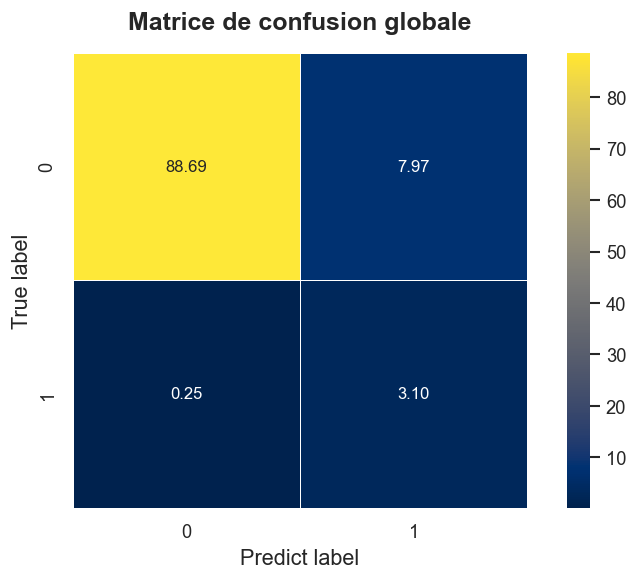

In [8]:
cm = confusion_matrix(
    y_test.ravel(),
    y_pred.ravel(),
)
cm_percent = cm / cm.sum().sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))

heatmap = sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot_kws={"size": 10},
    ax=ax,
)
ax.set_title("Matrice de confusion globale", pad=14)
plt.xlabel("Predict label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

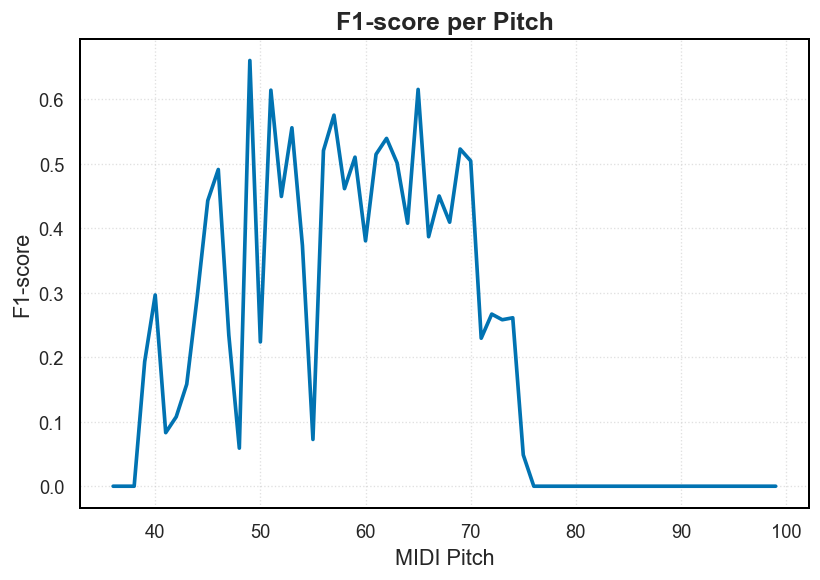

In [9]:
f1_scores = []

for k in range(y_test.shape[1]):
    score = f1_score(
        y_test[:, k],
        y_pred[:, k],
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    f1_scores.append(
        {
            "pitch_midi": k + 36,
            "f1_score": score,
        }
    )

df_scores = pd.DataFrame(f1_scores)

plt.figure(figsize=(7, 5))

plt.plot(
    df_scores["pitch_midi"],
    df_scores["f1_score"],
)
plt.title("F1-score per Pitch")
plt.xlabel("MIDI Pitch")
plt.ylabel("F1-score")

plt.tight_layout()
plt.show()

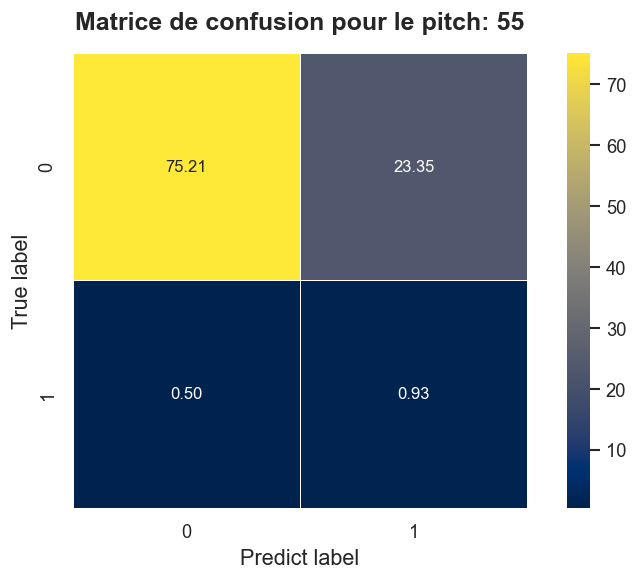

In [10]:
pitch = 55
y_true_pitch = y_test[:, pitch - 36]
y_pred_pitch = y_pred[:, pitch - 36]

cm = confusion_matrix(
    y_true_pitch,
    y_pred_pitch,
)
cm_percent = cm / cm.sum().sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))

heatmap = sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot_kws={"size": 10},
    ax=ax,
)
ax.set_title(f"Matrice de confusion pour le pitch: {pitch}", pad=14)
plt.xlabel("Predict label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

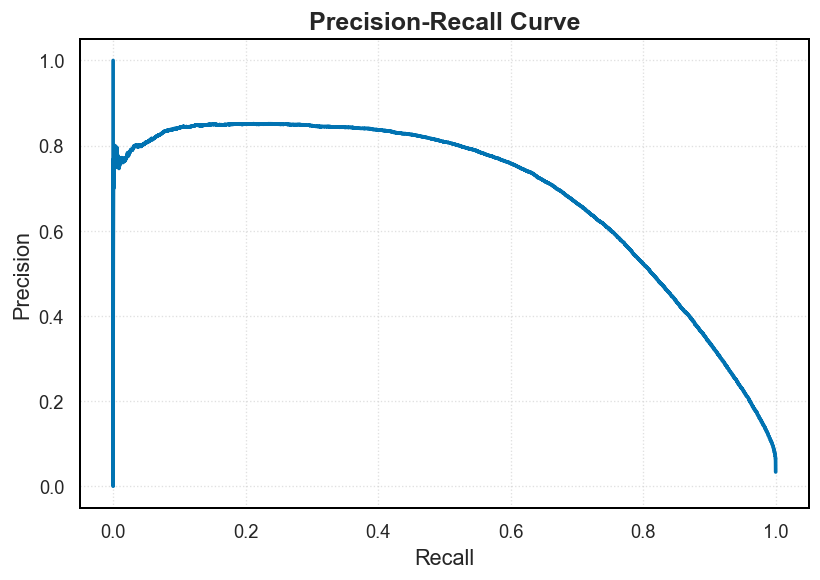

In [11]:
precision, recall, _ = precision_recall_curve(
    y_test.ravel(),
    y_prob.ravel(),
)

plt.figure(figsize=(7, 5))

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()

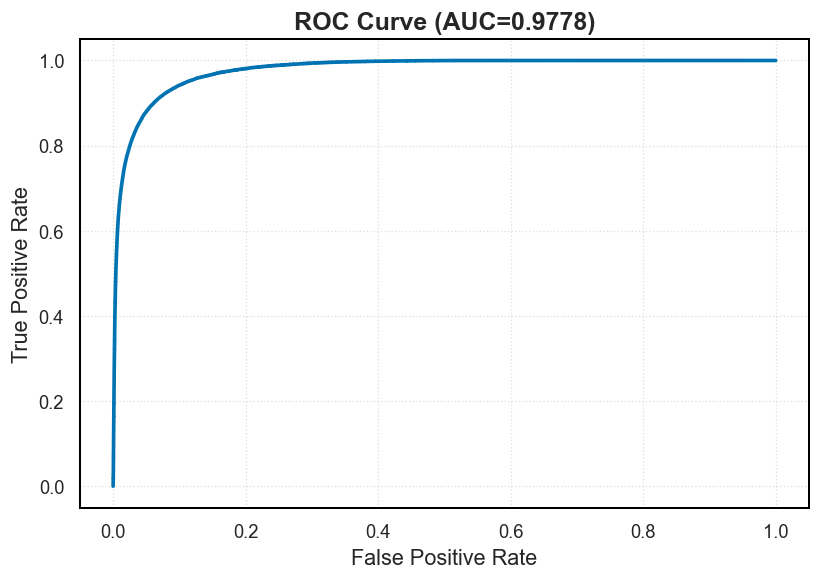

In [12]:
fpr, tpr, _ = roc_curve(
    y_test.ravel(),
    y_prob.ravel(),
)

auc_score = roc_auc_score(
    y_test,
    y_prob,
    average="micro",
)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={auc_score:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.tight_layout()
plt.show()

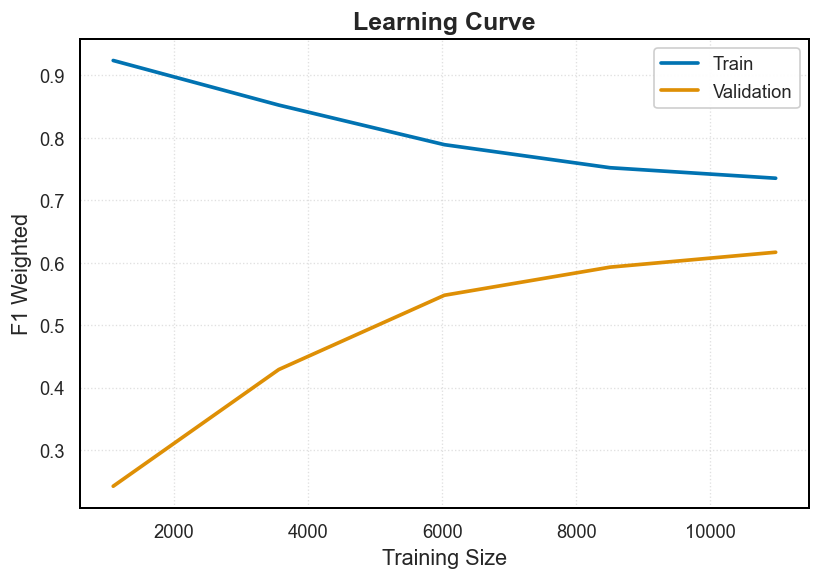

In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=cqt_baseline_mode,
    X=x_test,
    y=y_test,
    cv=5,
    scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7, 5))

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("F1 Weighted")
plt.legend()

plt.tight_layout()
plt.show()